# Step A — Single-node Denmark: optimal capacity mix

**Task (Assignment 1, part a):** Pick one country and calculate the optimal capacities for
renewable and non-renewable generators. Plot the dispatch for a summer and a winter week,
the annual electricity mix, and investigate the technology contributions using duration
curves / capacity factors.

**Model:** Single bus (Denmark), three extendable generators — combined wind, solar PV, CCGT.

**Requires in the working directory:**
- `DK_2015_merged.csv`
- `functions_to_investigate.py` (custom plotting helpers used below as `fti`)


## Imports

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pypsa


/Users/kenzomaetanimachholm/Desktop/DTU/Masters - Semester 2/Integrated Energy/Integrated-Energy-Grids-A1G21/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
%load_ext autoreload
%autoreload 2

## Load 2015 Danish data (demand, wind CF, solar CF)

In [4]:
dataframe_dk = pd.read_csv("DK_2015_merged.csv", index_col=0, sep=",", parse_dates=True)
demand_dk = dataframe_dk["DK_load_actual_entsoe_transparency"]
CF_wind = dataframe_dk["wind_cf_Unnamed: 1"]
CF_solar = dataframe_dk["pv_cf_Unnamed: 1"]
dataframe_dk.head()


,DK_load_actual_entsoe_transparency,pv_cf_Unnamed: 1,wind_cf_Unnamed: 1
utc_timestamp,,,
2015-01-01 00:00:00+00:00,3100.00,0.0,0.537323
2015-01-01 01:00:00+00:00,3100.02,0.0,0.557632
2015-01-01 02:00:00+00:00,2980.39,0.0,0.583454
2015-01-01 03:00:00+00:00,2933.49,0.0,0.614832
2015-01-01 04:00:00+00:00,2941.54,0.0,0.644214


## Technology costs (2020 — DEA LCOE calculator)

Capital cost = Investment / lifetime + Fixed O&M. Marginal cost for CCGT comes from fuel
cost divided by efficiency + variable O&M. See Table 1.1 in the report.


In [5]:
data = {
    "capital_cost": [
        1500000/25 + 60000,   # wind:  120,000 $/MW/year
        800000/25 + 14000,    # solar:  46,000 $/MW/year
        700000/25 + 24000,    # CCGT:   52,000 $/MW/year
    ],
    "marginal_cost": [0.0, 0.0, 9.5 * 3.6 / 0.56 + 2.30]  # CCGT: ~63.4 $/MWh
}

costs = pd.DataFrame(data, index=["wind_combined", "solar", "CCGT"])
costs.head()


,capital_cost,marginal_cost
wind_combined,120000.0,0.000000
solar,46000.0,0.000000
CCGT,52000.0,63.371429


## Build the network

In [6]:
dnk_n = pypsa.Network()
dnk_n.set_snapshots(dataframe_dk.index.values)


In [7]:
# Single node for Denmark
dnk_n.add("Bus", "Denmark")


Index(['Denmark'], dtype='object')

In [8]:
# Carriers (technology labels; used for colouring)
carriers = ["wind_combined", "solar", "CCGT"]
dnk_n.add(
    "Carrier",
    carriers,
    color=["blue", "red", "brown"],
)


Index(['wind_combined', 'solar', 'CCGT'], dtype='object')

In [9]:
# Demand associated to the Denmark bus
dnk_n.add("Load", "dnk_demand", bus="Denmark", p_set=demand_dk.values)


Index(['dnk_demand'], dtype='object')

In [10]:
max_val = demand_dk.max()
max_time = demand_dk.idxmax()
print("Peak demand:", max_val, "MW at", max_time)


Peak demand: 5709.95 MW at 2015-01-20 16:00:00+00:00


<Axes: xlabel='snapshot', ylabel='MW'>

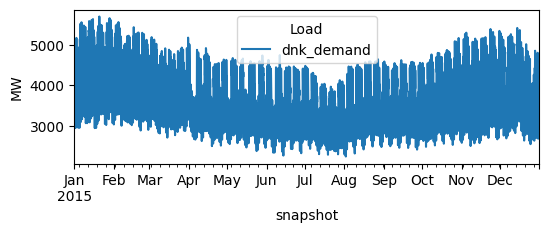

In [11]:
dnk_n.loads_t.p_set.plot(figsize=(6, 2), ylabel="MW")


## Generators (extendable — capacity will be optimised)

In [12]:
# wind onshore (combined)
dnk_n.add(
    "Generator",
    "wind_combined",
    bus="Denmark",
    carrier="wind_combined",
    capital_cost=costs.loc["wind_combined", "capital_cost"],
    marginal_cost=costs.loc["wind_combined", "marginal_cost"],
    p_max_pu=CF_wind.values,
    p_nom_extendable=True,
)


Index(['wind_combined'], dtype='object')

In [13]:
# solar
dnk_n.add(
    "Generator",
    "solar",
    bus="Denmark",
    carrier="solar",
    capital_cost=costs.loc["solar", "capital_cost"],
    marginal_cost=costs.loc["solar", "marginal_cost"],
    p_max_pu=CF_solar.values,
    p_nom_extendable=True,
)


Index(['solar'], dtype='object')

In [14]:
# CCGT — efficiency 0.58 is applied by PyPSA to translate fuel marginal cost to electrical
dnk_n.add(
    "Generator",
    "CCGT",
    bus="Denmark",
    carrier="CCGT",
    capital_cost=costs.loc["CCGT", "capital_cost"],
    marginal_cost=costs.loc["CCGT", "marginal_cost"],
    efficiency=0.58,
    p_nom_extendable=True,
)


Index(['CCGT'], dtype='object')

<Axes: xlabel='snapshot', ylabel='CF'>

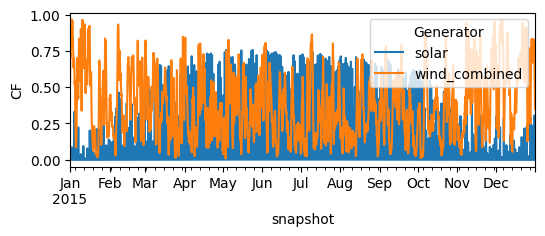

In [15]:
dnk_n.generators_t.p_max_pu.loc["2015"].plot(figsize=(6, 2), ylabel="CF")


## Optimise (capacity expansion, linear programming)

In [16]:
dnk_n.optimize(solver_name="gurobi")


Index(['Denmark'], dtype='object', name='Bus')
Index(['Denmark'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 67.68it/s]
INFO:linopy.io: Writing time: 0.23s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2706870


INFO:gurobipy:Set parameter LicenseID to value 2706870


...

Solved in 1042 iterations and 0.45 seconds (0.35 work units)


INFO:gurobipy:Solved in 1042 iterations and 0.45 seconds (0.35 work units)


Optimal objective  1.872718568e+09


INFO:gurobipy:Optimal objective  1.872718568e+09
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 26283 primals, 61323 duals
Objective: 1.87e+09
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


('ok', 'optimal')

## Results — raw printouts

In [17]:
# Objective value [USD/year]
print("objective value: ", dnk_n.objective)


objective value:  1872718567.614339


In [18]:
# Installed capacities [MW]
print("in MW \n", dnk_n.generators.p_nom_opt)


in MW 
 Generator
wind_combined    6100.444823
solar            3265.428127
CCGT             5336.670712
Name: p_nom_opt, dtype: float64


In [19]:
# Hourly production per technology [MW]
hourly_prod = dnk_n.generators_t.p
print(hourly_prod)
# dnk_n.generators_t.p.to_csv("hourly_dnk_production.csv")


Generator            wind_combined  solar         CCGT
snapshot                                              
2015-01-01 00:00:00    3100.000000    0.0     0.000000
2015-01-01 01:00:00    3100.020000    0.0     0.000000
2015-01-01 02:00:00    2980.390000    0.0     0.000000
2015-01-01 03:00:00    2933.490000    0.0     0.000000
2015-01-01 04:00:00    2941.540000    0.0     0.000000
...                            ...    ...          ...
2015-12-31 19:00:00    2581.488633    0.0  1106.381367
2015-12-31 20:00:00    2540.780365    0.0   994.769635
2015-12-31 21:00:00    2381.107322    0.0  1008.152678
2015-12-31 22:00:00    2160.667748    0.0  1101.602252
2015-12-31 23:00:00    2115.262137    0.0  1043.587863

[8760 rows x 3 columns]


In [20]:
# Annual production per technology [TWh]
print(" in TWh \n", dnk_n.generators_t.p.sum() / 1e6)


 in TWh 
 Generator
wind_combined    18.745708
solar             2.818124
CCGT             11.250316
dtype: float64


In [21]:
# Hourly income per technology (production × price) [$/h]
hourly_income = dnk_n.generators_t.p.multiply(dnk_n.buses_t.marginal_price.to_numpy())
print(hourly_income)


Generator            wind_combined  solar          CCGT
snapshot                                               
2015-01-01 00:00:00       0.000000    0.0      0.000000
2015-01-01 01:00:00       0.000000    0.0      0.000000
2015-01-01 02:00:00       0.000000    0.0      0.000000
2015-01-01 03:00:00       0.000000    0.0      0.000000
2015-01-01 04:00:00       0.000000    0.0      0.000000
...                            ...    ...           ...
2015-12-31 19:00:00  163592.622512    0.0  70112.967773
2015-12-31 20:00:00  161012.881395    0.0  63039.972890
2015-12-31 21:00:00  150894.172569    0.0  63888.075430
2015-12-31 22:00:00  136924.601872    0.0  69810.108413
2015-12-31 23:00:00  134047.183450    0.0  66133.653693

[8760 rows x 3 columns]


In [22]:
# Annual income per technology [$/y]
incomes_y = dnk_n.generators_t.p.multiply(dnk_n.buses_t.marginal_price.to_numpy()).sum()
print(incomes_y)


Generator
wind_combined    7.320534e+08
solar            1.502097e+08
CCGT             9.904555e+08
dtype: float64


In [23]:
# Annual costs per technology (capex + opex) [$/y]
costs_y = dnk_n.statistics.capex().add(dnk_n.statistics.opex(), fill_value=0)
print(costs_y)


component  carrier      
Generator  CCGT             9.904555e+08
           solar            1.502097e+08
           wind_combined    7.320534e+08
dtype: float64


In [24]:
# Hourly energy prices (marginal price at the Denmark bus) [$/MWh]
energy_prices = dnk_n.buses_t.marginal_price


In [25]:
# Scarcity revenue = revenue − opex. For the marginal technology at the optimum it
# should equal capex (zero-profit condition for extendable generators).
revenue = dnk_n.statistics.revenue(groupby=False)
opex = dnk_n.statistics.opex(groupby=False)

scarsity_revenue = revenue.sub(opex, fill_value=0)
print(scarsity_revenue.loc["Generator"])
print(dnk_n.statistics.capex())


Generator
CCGT             2.775069e+08
solar            1.502097e+08
wind_combined    7.320534e+08
dtype: float64
component  carrier      
Generator  CCGT             2.775069e+08
           solar            1.502097e+08
           wind_combined    7.320534e+08
dtype: float64


## Plots (via the `functions_to_investigate` helper module)

These wrap matplotlib around the optimised network for dispatch weeks, duration curves,
the annual mix, mismatch analysis, installed capacity and system costs.


In [26]:
import importlib
import functions_to_investigate as fti


<Axes: title={'center': 'Generation Mix & Storage (2015-08-01 to 2015-08-08)'}, xlabel='snapshot', ylabel='Power [MW]'>

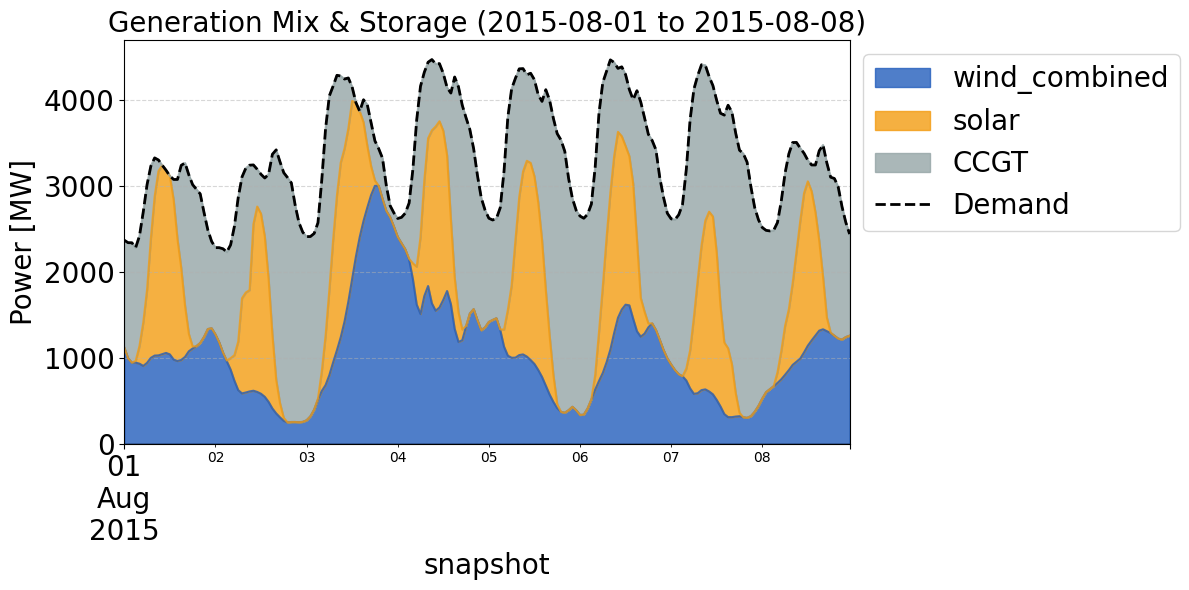

In [46]:
fti.plot_generation_mix(dnk_n, '2015-08-01', '2015-08-08')


<Axes: title={'center': 'Generation Mix & Storage (2015-02-20 to 2015-02-27)'}, xlabel='snapshot', ylabel='Power [MW]'>

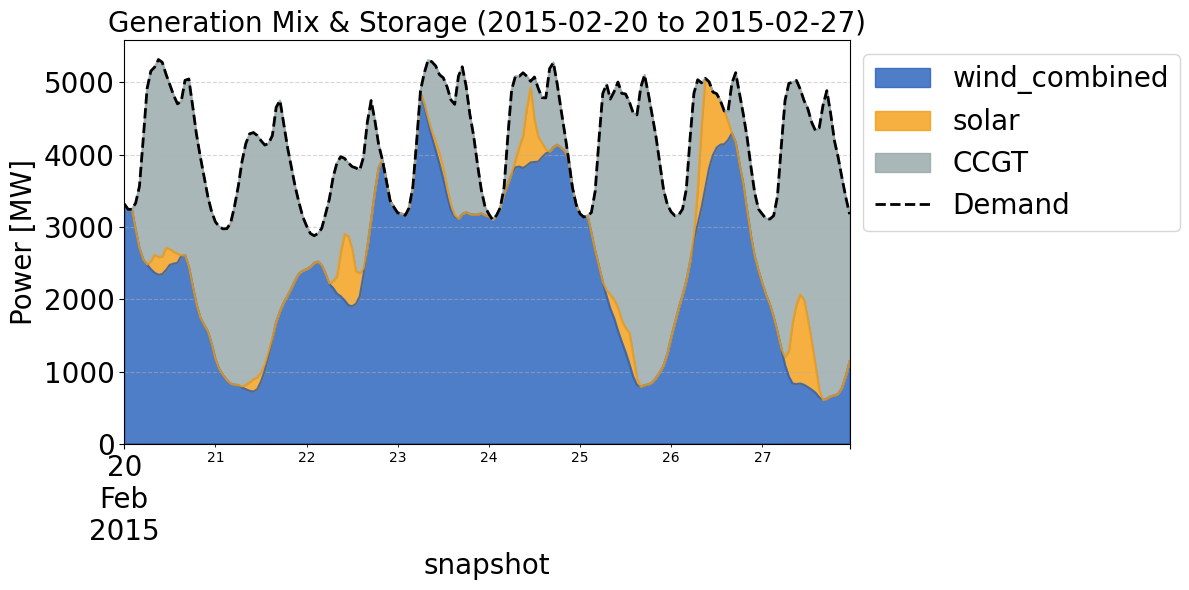

In [47]:
fti.plot_generation_mix(dnk_n, '2015-02-20', '2015-02-27')


In [29]:
fti.calculate_system_metrics(dnk_n, '2015-07-01', '2015-08-31')


------------------------------
METRICS (2015-07-01 to 2015-08-31)
------------------------------
Average Capacity Factors [%]:
  * wind_combined  :  28.37%
  * solar          :  16.47%
  * CCGT           :  21.13%

Total Backup Energy (CCGT): 1.678 TWh
Renewable Share:         66.80%
------------------------------


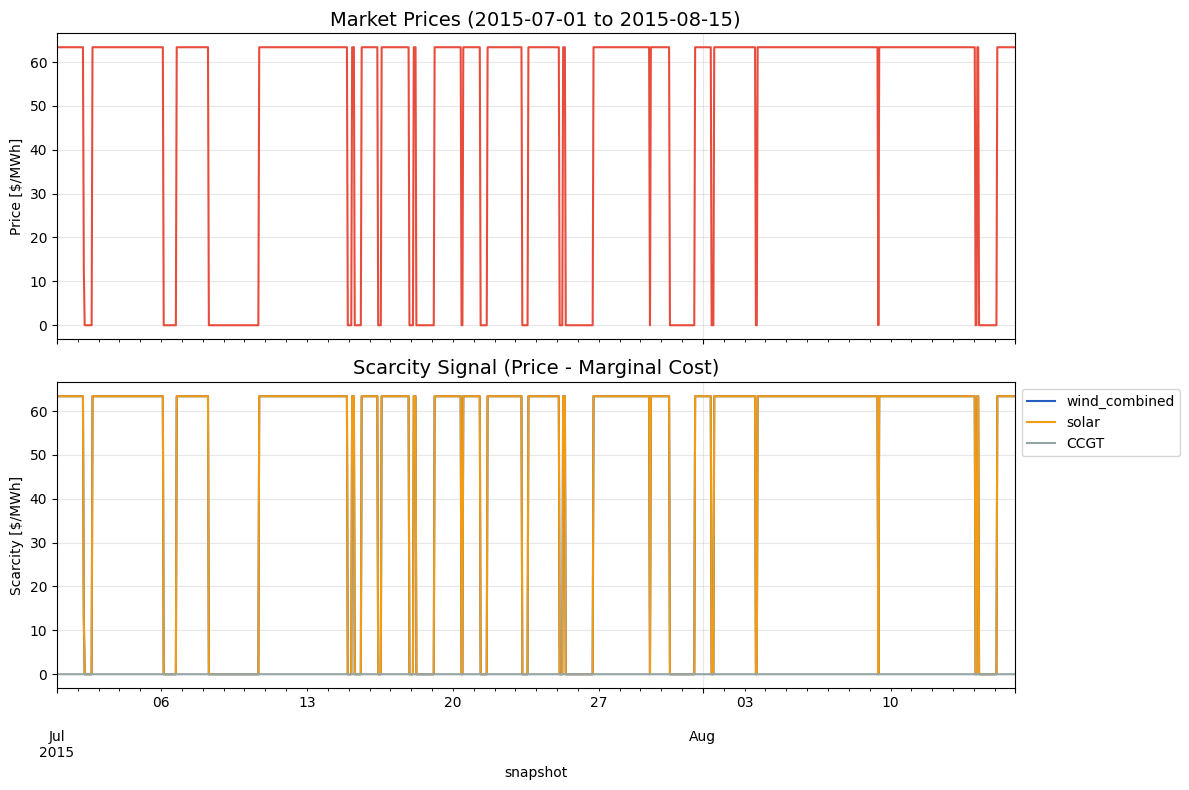

In [30]:
fti.plot_prices_and_scarcity(dnk_n, '2015-07-01', '2015-08-15')


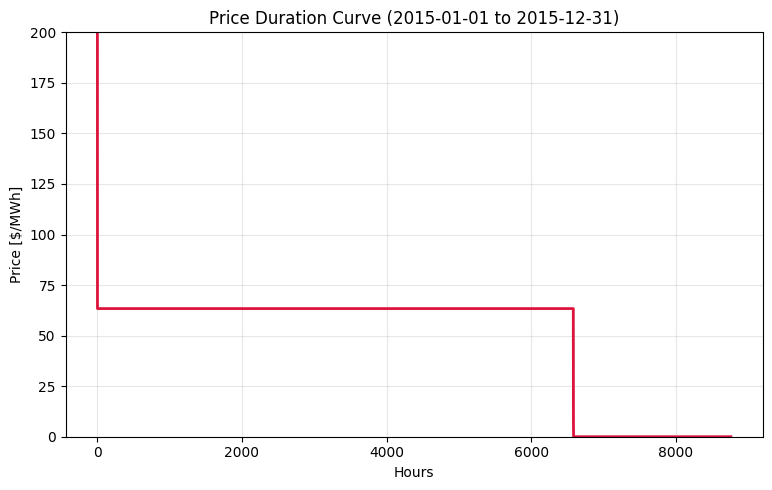

In [31]:
fti.plot_price_duration_curve(dnk_n, '2015-01-01', '2015-12-31')


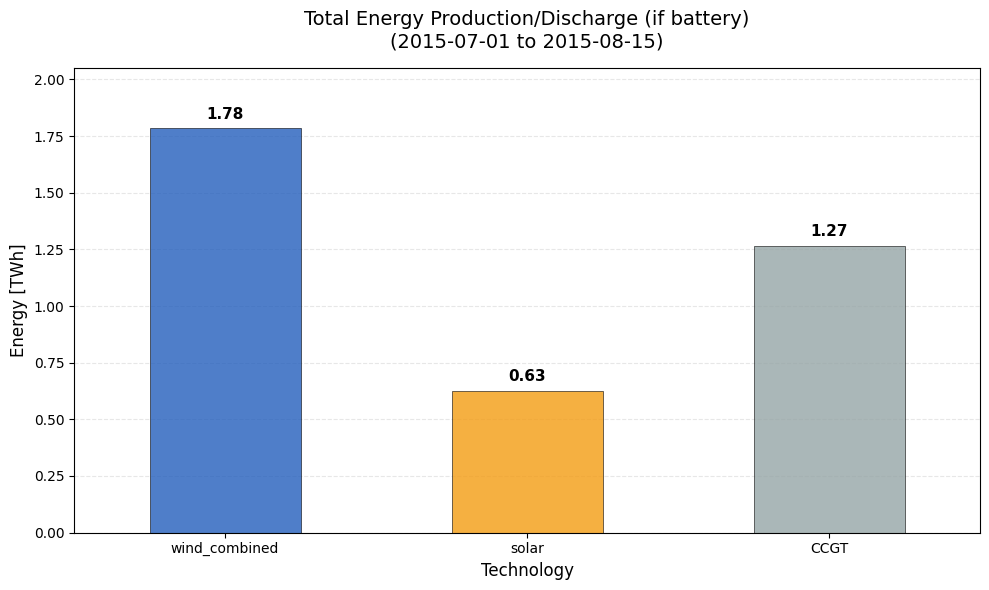

In [32]:
fti.plot_energy_production(dnk_n, '2015-07-01', '2015-08-15')


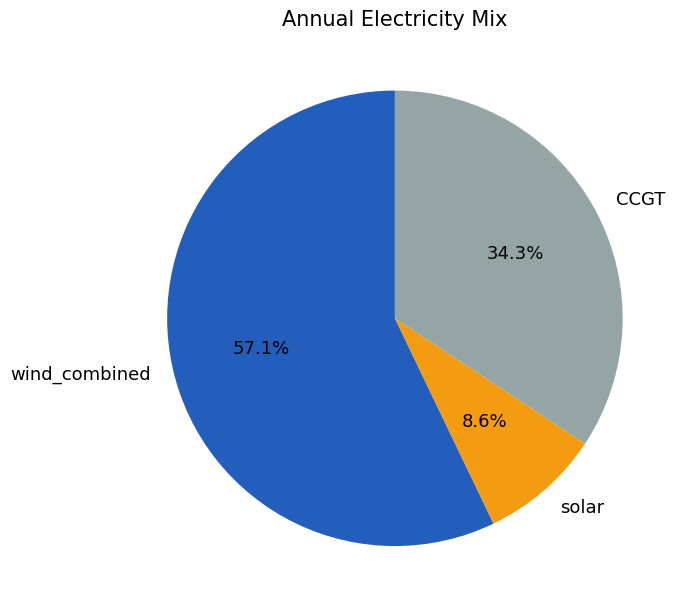

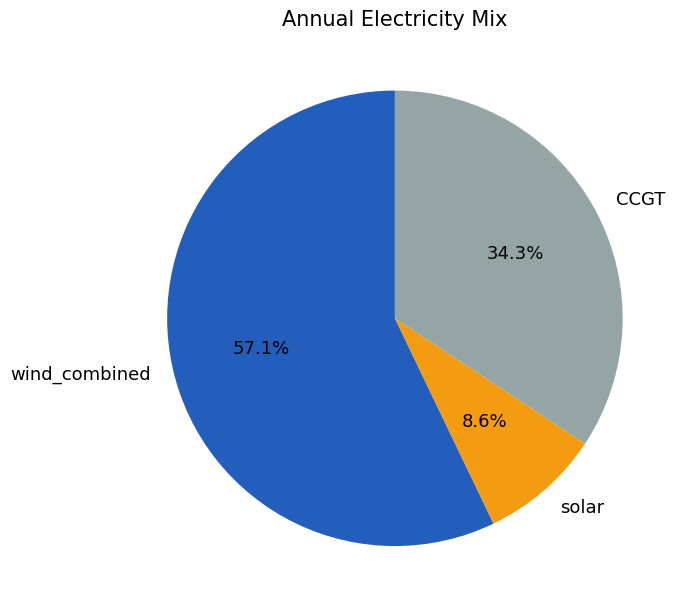

/var/folders/np/y0lp2y655xv_szx354zcxsmh0000gn/T/ipykernel_42185/2172910368.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=20)
/var/folders/np/y0lp2y655xv_szx354zcxsmh0000gn/T/ipykernel_42185/2172910368.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=20)


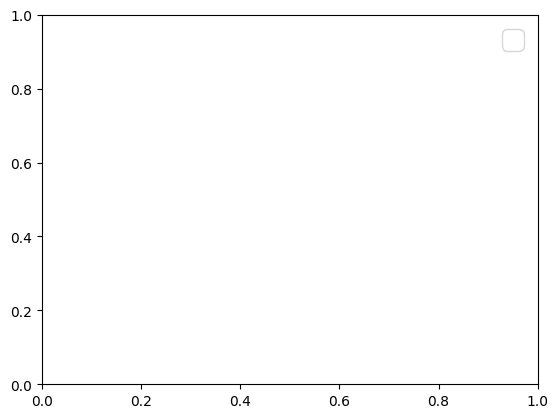

In [45]:
fti.plot_annual_mix(dnk_n)



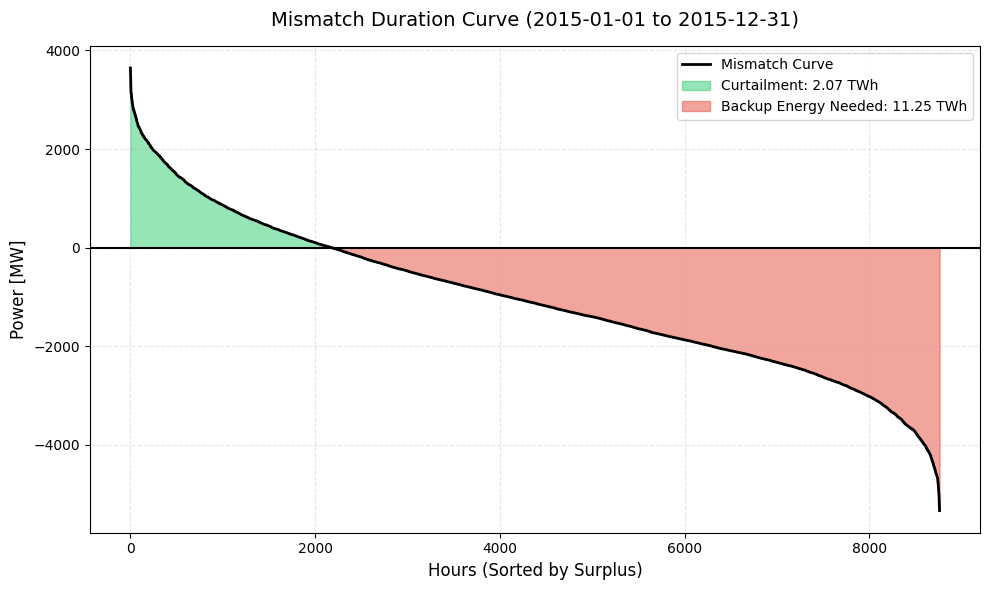

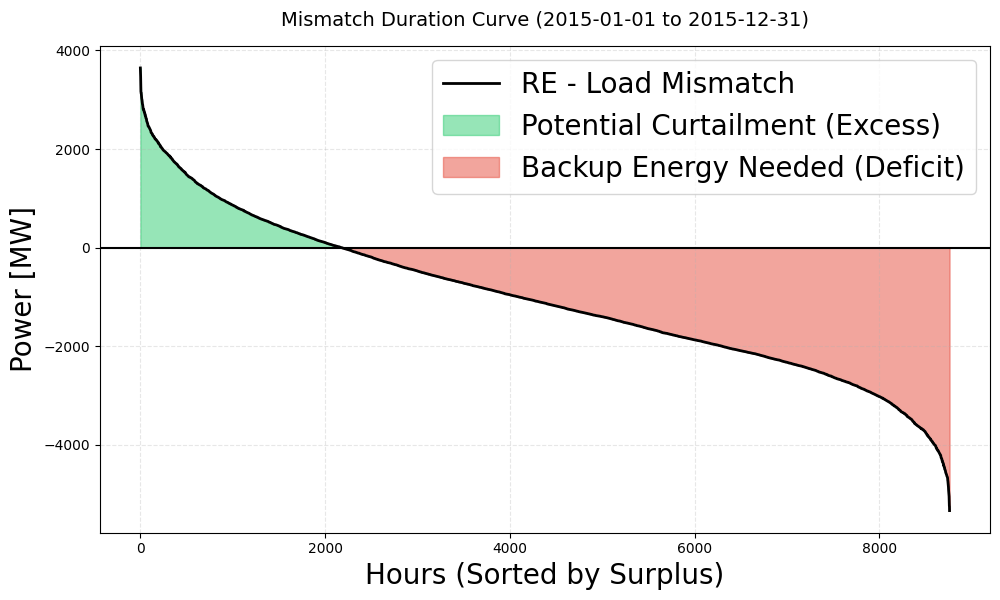

In [44]:
fti.plot_mismatch_analysis(dnk_n, '2015-01-01', '2015-12-31')
ax = fti.plot_mismatch_analysis(dnk_n, '2015-01-01', '2015-12-31')
plt.xlabel(plt.gca().get_xlabel(), fontsize=20)
plt.ylabel(plt.gca().get_ylabel(), fontsize=20)
plt.legend(fontsize=20)
plt.ylabel(plt.gca().get_ylabel(), fontsize=20)
plt.legend(fontsize=20)


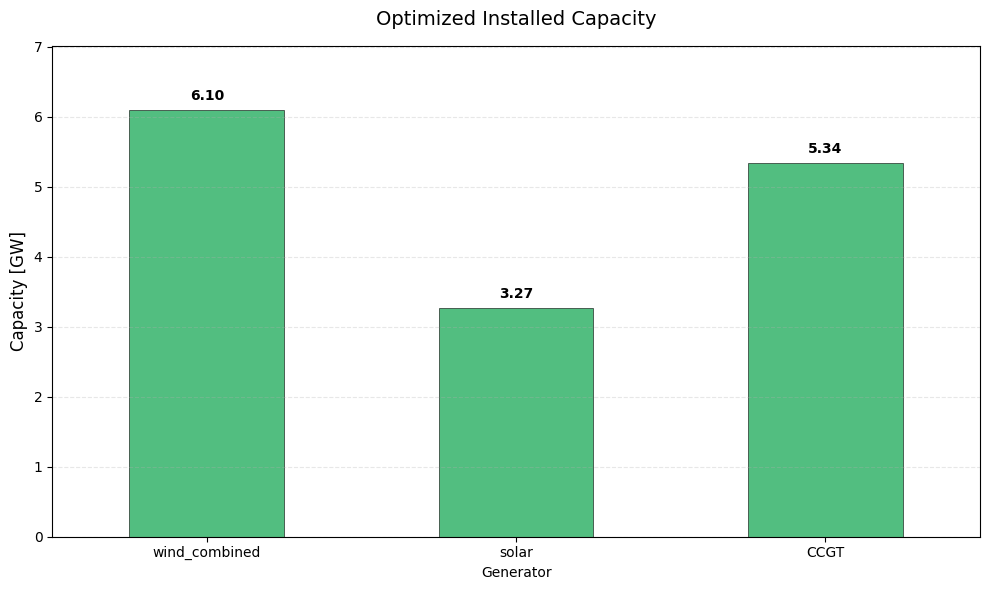

In [35]:
fti.plot_installed_capacity(dnk_n)


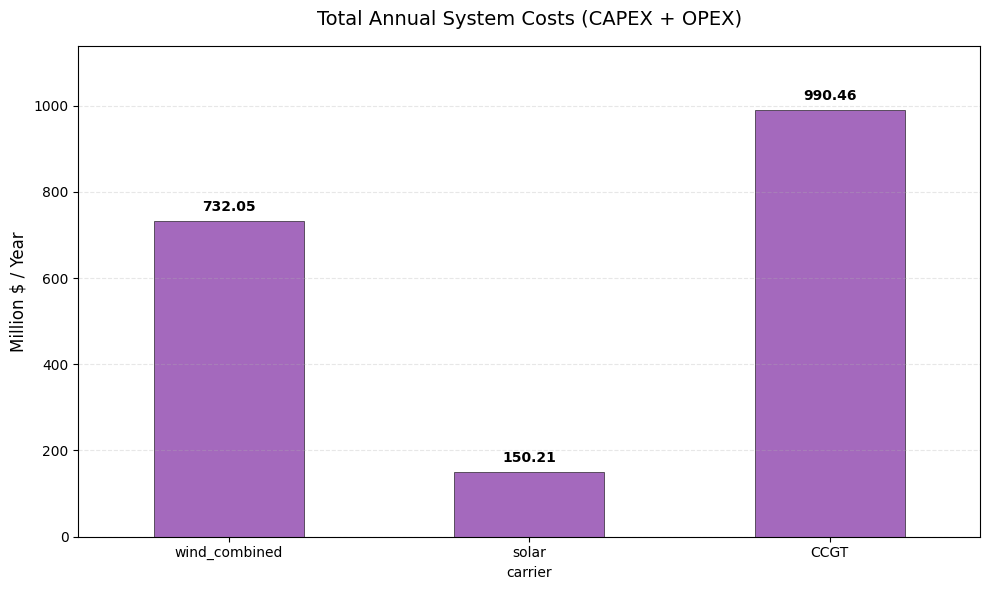

In [36]:
fti.plot_system_costs(dnk_n)
